# ML from DFT data

- [ ] learn on separated FM and NM AGAIN
- [ ] remove high order BOP features before learing
- [ ] Recursive Feature elimination after removing high order features
- [ ] make recursion on bond energy
- [ ] change OS to 1/10,
- [ ] 1/10 OS and scf bop
- learn form library features
- compare different regression methods
   - Linear regression
   - add SVM
   - kernel methods
   - Gaussian process.
- compare different test-train splittings
- Learn on increasing domain knowledge

 - input: clean features dataframes from pickles
 - output : plots and Models

In [1]:
from Tools.DatasetTools.Commoms import *

In [2]:
plt.rc('figure', figsize=(18, 8))
plt.rc('font', size=22)
from matplotlib.lines import Line2D

# Parameters 

In [3]:
from Tools.DatasetTools.DatasetOperator import Dataset

In [4]:
DS = Dataset('Fe-Mo')

In [ ]:
ModelName = 'MLP'

# Targets

Text(0.5, 0, '$V_0$')

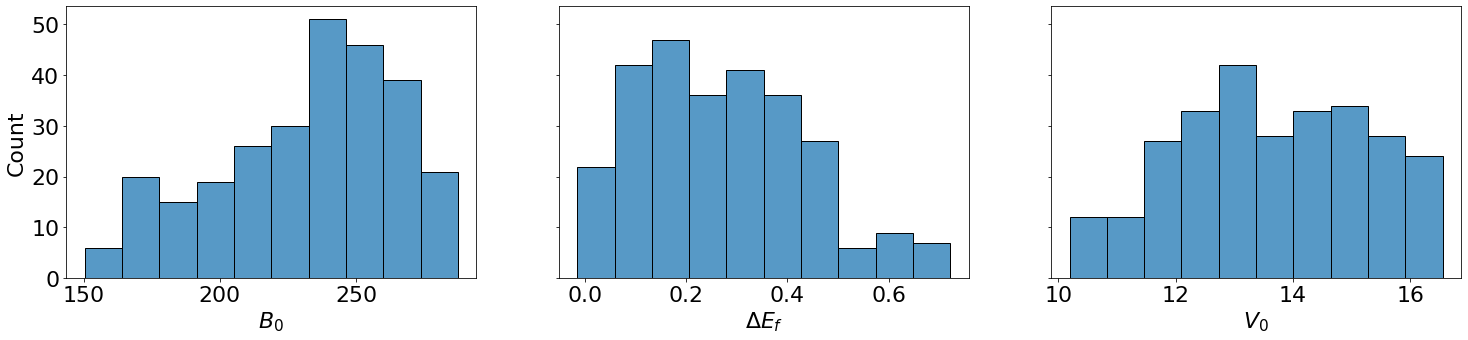

In [5]:
fig, ax = plt.subplots(1,3, figsize=(25, 5), sharey = True)
sns.histplot( DS.BS['B0'], ax= ax[0])
sns.histplot( DS.BS['EF'], ax= ax[1])
sns.histplot( DS.BS['V0'], ax= ax[2])
ax[0].set_xlabel('$B_0$')
ax[1].set_xlabel('$\Delta E_f$')
ax[2].set_xlabel('$V_0$')

# Machine Learning 

In [6]:
from Tools.DatasetTools.MLConveniences import *

In [7]:
resultslocation = DS.resultslocation

## Feature sets

In [8]:
Features = DS.Features  # {name: pd.read_pickle(filename) for name, filename in DescriptorFileList.items()}

In [9]:
Features['Canonical BOP']

,Structure,Mag,U_bind,U_bond_atom_list_1_0,U_bond_atom_list_1_CN12,U_bond_atom_list_1_CN13,U_bond_atom_list_1_CN14,U_bond_atom_list_1_CN15,U_bond_atom_list_1_CN16,moments_1_0,...,Binf_1_CN14,Binf_1_CN15,Binf_1_CN16,sf_0,sf_CN12,sf_CN13,sf_CN14,sf_CN15,sf_CN16,random
Fe_pv8Mo_sv22.sigma-BBABB.FM,10,0,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.790157
Fe_pv10Mo_sv20.sigma-ABBAB.FM,10,0,-78.594335,-7.771059,-1.424594,0.000000,-5.906606,-0.439859,0.000000,1.201761,...,0.668575,0.166260,0.000000,1.224174,1.311938,0.000000,1.187308,1.155463,0.000000,0.021185
Fe_pv4Mo_sv20.C36-ABBBB.FM,3,0,-94.449166,-8.534487,-7.595698,0.000000,0.000000,0.000000,-0.938789,1.303069,...,0.000000,0.000000,0.501537,1.081732,1.156282,0.000000,0.000000,0.000000,0.901327,0.518125
Fe_pv5Mo_sv24.chi-AABB.FM,6,0,-116.205661,-8.244366,-6.070495,-1.652565,0.000000,0.000000,-0.521305,1.162619,...,0.000000,0.000000,0.186186,1.251703,1.437268,1.179083,0.000000,0.000000,1.006205,0.727679
Fe_pv15Mo_sv38.R-AAAABBBBBBB.NM,4,1,-121.105805,-8.136275,-2.533063,0.000000,-0.844603,-0.318349,-4.440260,1.218738,...,0.256809,0.124851,0.170809,1.192249,1.343509,0.000000,1.139857,0.956735,0.947607,0.321009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,9,1,-40.035290,-8.020136,-2.520056,0.000000,-0.663807,-0.397166,-4.439107,1.265062,...,0.220371,0.224323,0.222761,1.071111,1.222567,0.000000,0.902499,0.748344,1.001884,0.789106
Fe_pv8Mo_sv22.sigma-BBABB.NM,10,1,-100.702297,-7.906327,-1.428383,0.000000,-6.005237,-0.472706,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.966103
Fe_pv1Mo_sv3.L12-AB3.FM,7,0,-12.617373,-6.832601,-6.832601,0.000000,0.000000,0.000000,0.000000,1.063750,...,0.000000,0.000000,0.000000,1.140024,1.140024,0.000000,0.000000,0.000000,0.000000,0.257890
Fe_pv8Mo_sv22.sigma-BBBBA.FM,10,0,-94.569986,-7.892530,-5.305761,0.000000,-2.136368,-0.450401,0.000000,1.174563,...,0.660966,0.164368,0.000000,1.224171,1.311938,0.000000,1.187302,1.155462,0.000000,0.320841


In [10]:
Features.keys()

dict_keys(['atomic', 'dataset', 'Pyscal', 'Canonical BOP', 'Projections BOP', 'Projections OS BOP', 'Projections sOS BOP', 'dataset + Canonical BOP', 'dataset + Projections BOP', 'dataset + Projections OS BOP', 'dataset + Projections sOS BOP'])

## BOP features with and without CP averages

In [11]:
def clean_CNAVS(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_CN)')
    else:
        return features

In [12]:
def clean_zeros(name:str, features:pd.core.frame.DataFrame):
    if 'BOP' in name:
        return features.filter(regex='^(?!.*_0$)')
    else:
        return features

In [13]:
def notyetclean(name:str):
    return ('BOP' in name) and ('CNAV' not in name) and ('Zeros' not in name)

In [14]:
Features.update({name+' no CNAV': clean_CNAVS(name, features) for name, features in Features.items() if notyetclean(name)})

In [15]:
# Features.update({name+' no Zeros': clean_zeros(name, features) for name, features in Features.items() if notyetclean(name)} )

## test - train splits

In [16]:
samplesplit = DS.get_samplesplit()#split_random_state=20091116) 
# RS state from commit 910c1e3d01bc3e50c361f58fc7504462ef73c8e1

# Models: adjust params

In [77]:
from importlib.machinery import SourceFileLoader
MO = SourceFileLoader('MO', 'Tools/DatasetTools/ModelSelection.py').load_module().ModelOptions(DS.dataset)

In [18]:
Models = {
    'MLP': Pipeline([('scaler', StandardScaler()), ('regressor', MLPRegressor())]),
}

In [71]:
MO.load_model_options('MLP')

UnboundLocalError: local variable 'thismodeloptions' referenced before assignment

In [76]:
MO.modeloptions

{}

In [21]:
samplefolds = list(DS.get_folds())

# fits

In [22]:
FittedModels = {}

In [23]:
Models

{'MLP': Pipeline(steps=[('scaler', StandardScaler()), ('regressor', MLPRegressor())])}

In [24]:
fittedmodelslocation = os.path.join(DS.resultslocation, 'MLP_FittedCVSearch.pkl')

if os.path.exists(fittedmodelslocation):
    with open(fittedmodelslocation, 'rb') as pkl:
        FittedModels = pickle.load(pkl)

In [25]:

for name, model in Models.items():
    print (name)
    progress = tqdm(Features.items())
    for key, features in progress: #Features.items():
        if 'no CNAV' in key:
            continue
        if (name, key) in FittedModels.keys():
            continue
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name],
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            verbose = 1,
            return_train_score= True,
        )
        FittedModels[(name, key)] = model.fit(features, DS.target)

MLP


  0%|          | 0/19 [00:00<?, ?it/s]

In [60]:
Parameters = MO.modeloptions

In [55]:
MO.modeloptions['MLP']['regressor__hidden_layer_sizes'] = [(20,4), (40,4)]

In [26]:
with open(fittedmodelslocation, 'wb') as pkl:
    pickle.dump(FittedModels, pkl)

In [83]:
collect_best_scores = SourceFileLoader('collect_best_scores', 'Tools/DatasetTools/MLConveniences.py').load_module().collect_best_scores

In [84]:
FittedModels.keys()

dict_keys([('MLP', 'atomic'), ('MLP', 'dataset'), ('MLP', 'Pyscal'), ('MLP', 'Canonical BOP'), ('MLP', 'Projections BOP'), ('MLP', 'Projections OS BOP'), ('MLP', 'Projections sOS BOP'), ('MLP', 'dataset + Canonical BOP'), ('MLP', 'dataset + Projections BOP'), ('MLP', 'dataset + Projections OS BOP'), ('MLP', 'dataset + Projections sOS BOP')])

In [85]:
best_scores = collect_best_scores(FittedModels)

In [86]:
best_scores

test     train
MLP Projections BOP                0.045987  0.027082
    Projections sOS BOP            0.046313  0.028295
    dataset + Projections BOP      0.046469  0.026138
    dataset + Projections sOS BOP  0.047217  0.026764
    Projections OS BOP             0.049549  0.027499
    dataset + Projections OS BOP   0.050516  0.027896
    dataset + Canonical BOP        0.051715  0.027664
    Canonical BOP                  0.064967  0.035016
    dataset                        0.079113  0.038819
    Pyscal                         0.156031  0.146370
    atomic                         0.168560  0.142985

In [87]:
best_combi = best_scores.idxmin()['test']

In [88]:
best_combi

('MLP', 'Projections BOP')

In [89]:
results = pd.DataFrame.from_dict(FittedModels[best_combi].cv_results_)

In [90]:
results.sort_values(by='mean_test_score', ascending=False, inplace=True)

In [102]:
MO.modeloptions

{'MLP': {'regressor__random_state': [20091116],
  'regressor__max_iter': [1000],
  'regressor__alpha': [0.03, 0.04, 0.05, 0.06, 0.1],
  'regressor__learning_rate': ['adaptive'],
  'regressor__learning_rate_init': [0.001],
  'regressor__activation': ['logistic'],
  'regressor__hidden_layer_sizes': [(20, 4), (40, 4)],
  'regressor__solver': ['lbfgs']}}

In [107]:
results['param_regressor__hidden_layer_sizes'] = results['param_regressor__hidden_layer_sizes'].map(tuple)

In [108]:
for parameters in MO.modeloptions.values():
    print (parameters.keys())
    for key in parameters.keys():
        print (results.groupby(by='param_'+key)['mean_test_score'].max())

dict_keys(['regressor__random_state', 'regressor__max_iter', 'regressor__alpha', 'regressor__learning_rate', 'regressor__learning_rate_init', 'regressor__activation', 'regressor__hidden_layer_sizes', 'regressor__solver'])
param_regressor__random_state
20091116   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__max_iter
1000   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__alpha
0.03   -0.046084
0.04   -0.046848
0.05   -0.046503
0.06   -0.045987
0.10   -0.047317
Name: mean_test_score, dtype: float64
param_regressor__learning_rate
adaptive   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__learning_rate_init
0.001   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__activation
logistic   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__hidden_layer_sizes
(20, 4)   -0.046340
(40, 4)   -0.045987
Name: mean_test_score, dtype: float64
param_regressor__solver
lbfgs   -0.045987
Name: mean_test_score, dtype: float64

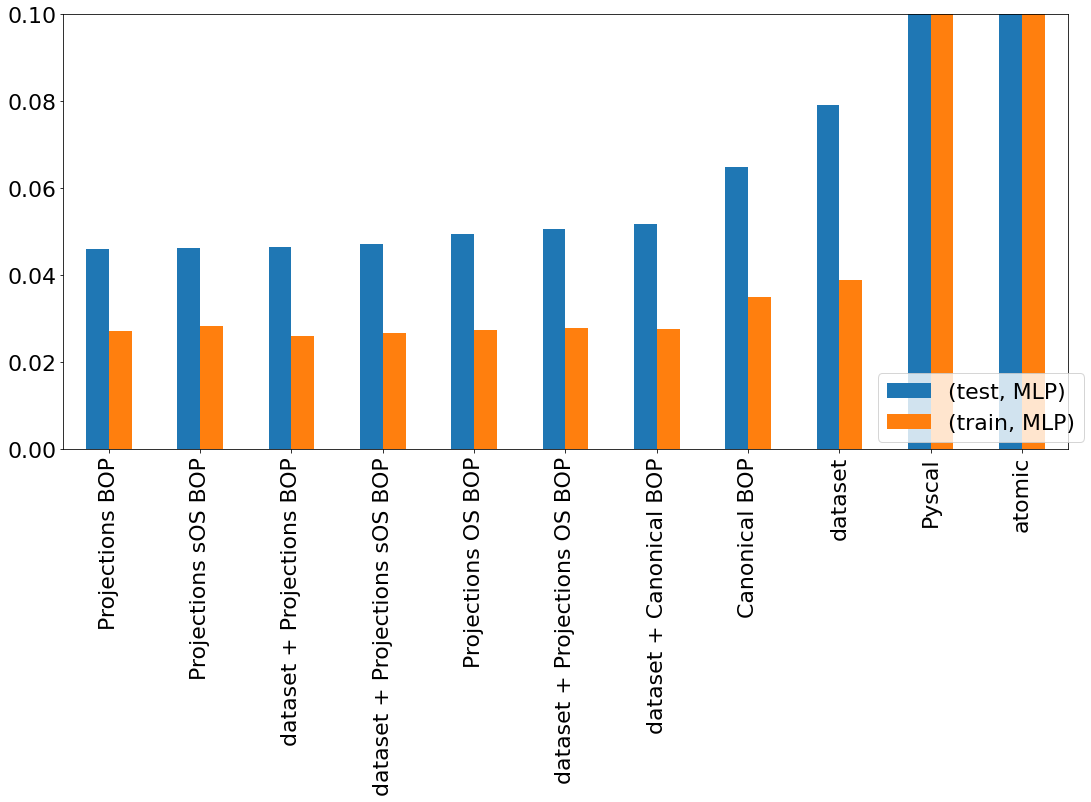

In [109]:
ax = best_scores.unstack(level=0).sort_values(by=('test','MLP')).plot.bar()
ax.set_ylim([0,0.1])
ax.legend(bbox_to_anchor=(0.8, 0.2))

In [110]:
FittedModels[best_combi].best_params_

{'regressor__activation': 'logistic',
 'regressor__alpha': 0.06,
 'regressor__hidden_layer_sizes': [40, 4],
 'regressor__learning_rate': 'adaptive',
 'regressor__learning_rate_init': 0.001,
 'regressor__max_iter': 1000,
 'regressor__random_state': 20091116,
 'regressor__solver': 'lbfgs'}

In [111]:
FittedModels[best_combi].best_score_

-0.045987290563353544

# Prediction line 

In [112]:
Prediction = {fname: model.predict(features) for (fname, features), model in zip(Features.items(),FittedModels.values())}

In [113]:
#iwanttoplot = {'atomic':'Matminer',
iwanttoplot = {'Canonical BOP':'Canonical BOP',  best_combi[1]: best_combi[1]}

In [114]:
pallete = sns.color_palette('magma_r', n_colors=len(iwanttoplot))

In [115]:
x_y = np.linspace(DS.target.min()-0.1, DS.target.max()+0.1, 2)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


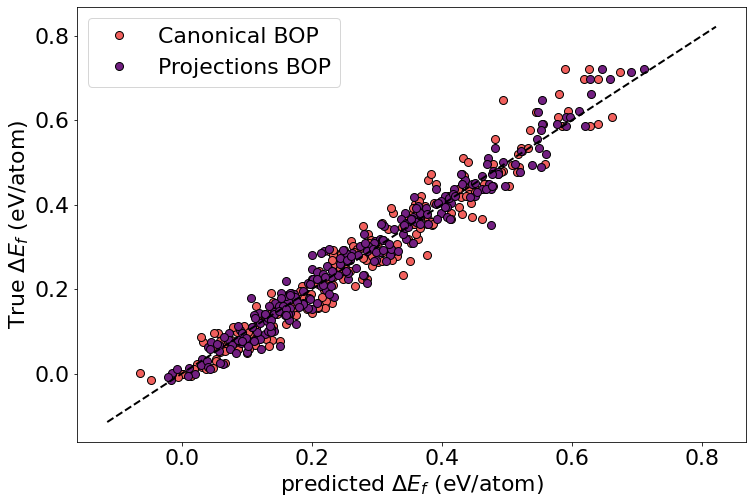

In [116]:
fig, ax = plt.subplots(figsize=(12,8))
for (name, legend), color in zip(iwanttoplot.items(), pallete):
    legend = legend.replace('dataset', 'polyhedra')
    ax.plot(Prediction[name], DS.target, 'o', markersize=8, markeredgecolor='k',  color = color, label=legend)
#    sns.scatterplot(Prediction[name], DS.target,ax=ax) #, markersize=8, markeredgecolor='k',  color = color, label=legend)
ax.set_xlabel(r'predicted $\Delta E_f$ (eV/atom)')
ax.set_ylabel(r'True $\Delta E_f$ (eV/atom)')
ax.legend()
ax.plot(x_y, x_y, '--k', lw=2)
fig.savefig(os.path.join(DS.dataset,'graphs', f'{DS.dataset}_predictionline.eps'))

# Recursivity

In [124]:
from importlib.machinery import SourceFileLoader
Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#from Tools.DatasetTools.DatasetOperator import Dataset
#DS = SourceFileLoader('DS', 'Tools/DatasetTools/DatasetOperator.py').load_module().Dataset('Fe-Mo')
#Tester = SourceFileLoader('Tester', 'Tools/DatasetTools/DatasetOperator.py').load_module().DatasetTester()
#samplesplit = DS.get_samplesplit()

In [120]:
import copy

In [121]:
RecursivityModels = copy.deepcopy(FittedModels)

In [125]:
test_scores = Tester.make_recursivity_anbn(DS, RecursivityModels, {'includemag':False})

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Tools/DatasetTools/DatasetOperator.py:219: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o-" (-> marker='o'). The keyword argument will take precedence.
  continue


(<Figure size 1296x576 with 1 Axes>,
 <AxesSubplot:xlabel='number of features', ylabel='test RMSE @ $\\Delta E_f$'>)

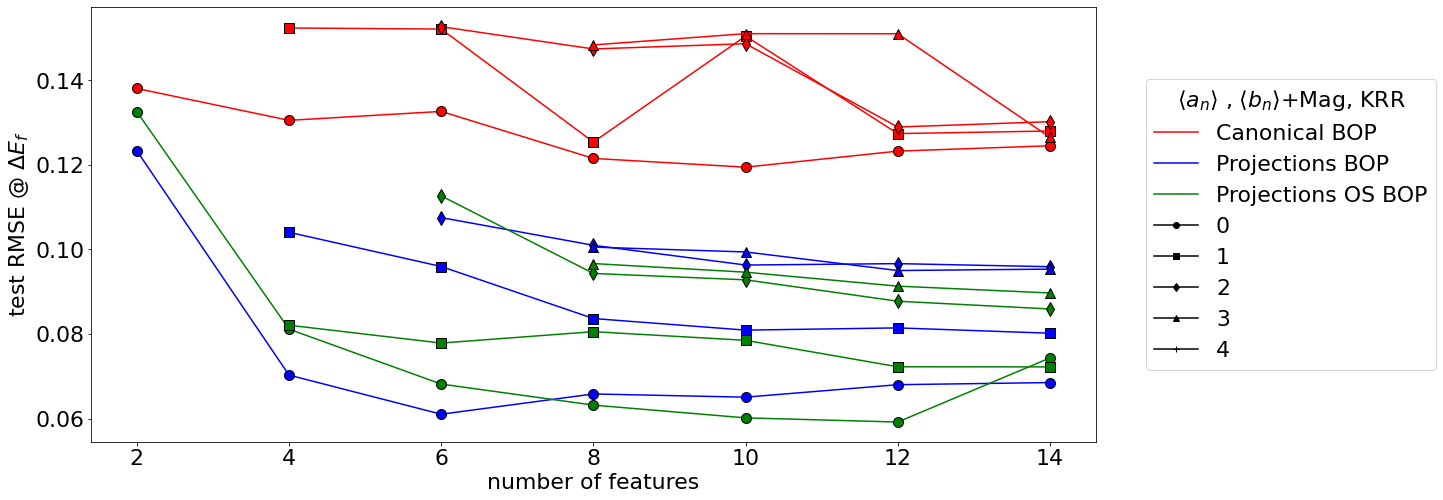

In [126]:
Tester.plot_recursivity_curve(test_scores, 'MLP', )

In [127]:
Modelname = 'MLP'

In [128]:
fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_{Modelname}_recursivity_anbn.pdf', bbox_inches='tight')

# Fits on reduced features 

In [129]:
ReducedFittedModels = {}

In [130]:
Reduced_features_fitting_location = os.path.join(DS.resultslocation, 'ReducedFeaturesCVSearch.pkl')

In [131]:
if os.path.exists(Reduced_features_fitting_location):
    with open(Reduced_features_fitting_location, 'rb') as pkl:
        ReducedFittedModels = pickle.load(pkl)

In [133]:
maxorders = [8,10,12,14,16]
for name, model in Models.items():
    progress = tqdm(product(Features.items(), maxorders), total=len(maxorders)*len(Features))
    for (key, features), maxorder in progress:  #maxorder in range(4,9):
        progress.set_description(name+', '+key+', '+str(maxorder)+':  ')
        if 'no CNAV' in key:
            continue
        if 'BOP' not in key:
            continue
        if 'Projections' not in key:
            continue
        if (name, key, maxorder) in ReducedFittedModels.keys():
            continue
        if maxorder < 10:
            regexstr = f'^(?!.*_[{maxorder}-9]_.*|.*_1[0-9]_.*)'
        else:
            regexstr = f'^(?!.*_1[{maxorder - 10}-9]_.*)'
#        for key, features in progress: #Features.items():
        model = GridSearchCV(
            Models[name],
            MO.modeloptions[name], 
            scoring='neg_root_mean_squared_error', 
            cv = samplefolds,
            return_train_score= True,
        )
        if 'BOP' in key :
            reducedfeatures = features.filter(regex=regexstr)
        else:
            reducedfeatures = features
        ReducedFittedModels[(name, key, maxorder)] = model.fit(reducedfeatures, DS.target)

  0%|          | 0/95 [00:00<?, ?it/s]

In [134]:
with open(Reduced_features_fitting_location, 'wb') as pkl:
    pickle.dump(ReducedFittedModels, pkl)

In [135]:
best_combi 

('MLP', 'Projections BOP')

In [136]:
somecombi = (Modelname, 'Projections BOP')

In [137]:
features_in_reduced = pd.Index(ReducedFittedModels[somecombi+(16,)].feature_names_in_)

In [138]:
features_in = pd.Index(FittedModels[somecombi].feature_names_in_)

In [139]:
features_in.difference(features_in_reduced)

Index([], dtype='object')

In [140]:
best_scores_reduced = collect_best_scores(ReducedFittedModels)

In [141]:
model = best_scores_reduced.index.get_level_values(0)

In [142]:
test_scores_vs_max = best_scores_reduced.unstack().transpose().loc['test'].dropna(axis=1)

In [144]:
test_scores_vs_max[Modelname]

,Projections BOP,Projections OS BOP,Projections sOS BOP,dataset + Projections BOP,dataset + Projections OS BOP,dataset + Projections sOS BOP
8,0.045190,0.049304,0.046674,0.046022,0.050817,0.046039
10,0.045219,0.049818,0.044921,0.045405,0.049841,0.045148
12,0.045985,0.050348,0.045439,0.045753,0.050484,0.046024
14,0.045148,0.048169,0.045668,0.046293,0.050222,0.046234
16,0.045535,0.049365,0.045455,0.046200,0.050757,0.046854


In [145]:
full_model_test_scores = best_scores.unstack().transpose().loc['test']

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


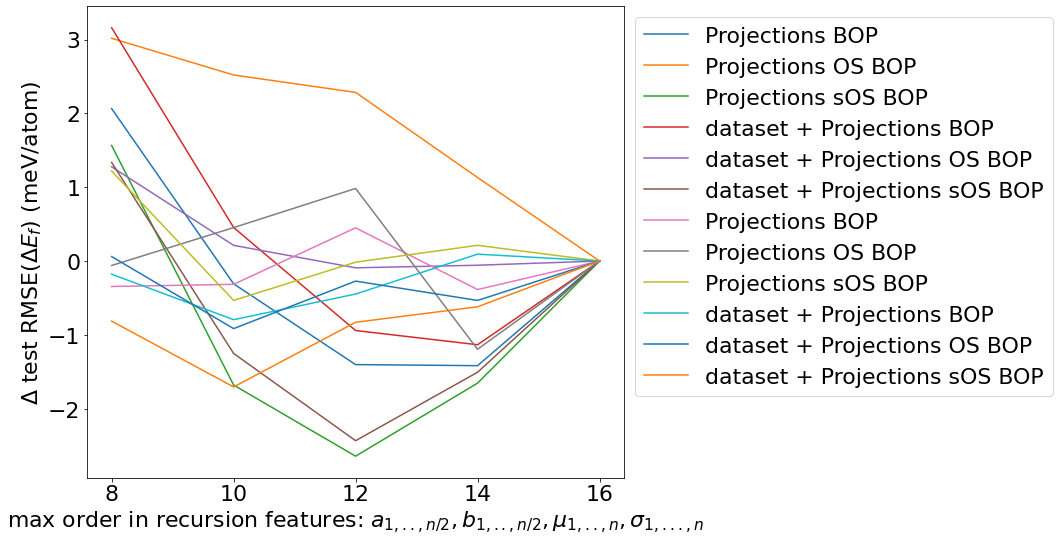

In [146]:
fig, ax = plt.subplots(figsize=(15,8))
for combi in test_scores_vs_max.columns:
#    if 'BOP' not in combi[1]:
#        continue
#    if 'Canonical' in combi[1]:
#        continue
#    if 'dataset' not in combi[1]:
#        continue
    drmse = (test_scores_vs_max[combi].values -test_scores_vs_max[combi].values[-1])*1000 #- full_model_test_scores[combi[0]][combi[1]]*1000
    l = ax.plot(test_scores_vs_max[combi].index,drmse , label=combi[1])[0]
#    ax.axhline(full_model_test_scores[combi[0]][combi[1]]*1000,ls='--', color=l.get_color())
ax.legend(bbox_to_anchor = (1,1))
ax.set_ylabel(r'$\Delta$ test RMSE($\Delta E_f$) (meV/atom)')
ax.set_xlabel(r'max order in recursion features: $a_{1,..,n/2}, b_{1,..,n/2}, \mu_{1,..,n}, \sigma_{1,...,n}$')
fig.tight_layout()
fig.savefig(os.path.join(DS.dataset, 'graphs', f'{DS.dataset}_full_recursivity.eps'))

# Feature Importances 

In [147]:
from sklearn.inspection import permutation_importance

In [148]:
get_importances = SourceFileLoader('get_importances', 'Tools/DatasetTools/MLConveniences.py').load_module().get_importances

In [149]:
importances = {}
for (modelname, name), estimator in FittedModels.items():
    print(name)
    allimportances = get_importances(estimator.best_estimator_ , DS.Features[name], DS.target)
    importances[(modelname, name)] =allimportances[allimportances['importances_mean']>=allimportances['importances_mean']['random']]

atomic
dataset
Pyscal
Canonical BOP
Projections BOP
Projections OS BOP
Projections sOS BOP
dataset + Canonical BOP
dataset + Projections BOP
dataset + Projections OS BOP
dataset + Projections sOS BOP


In [150]:
for (modelname, name),timportances in importances.items():
    timportances.sort_values(by='importances_mean', inplace=True, ascending=False)

/tmp/ipykernel_15411/281972631.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timportances.sort_values(by='importances_mean', inplace=True, ascending=False)


In [151]:
get_str_formatted = SourceFileLoader('get_str_formatted', 'Tools/DatasetTools/Tools.py').load_module().get_str_formatted

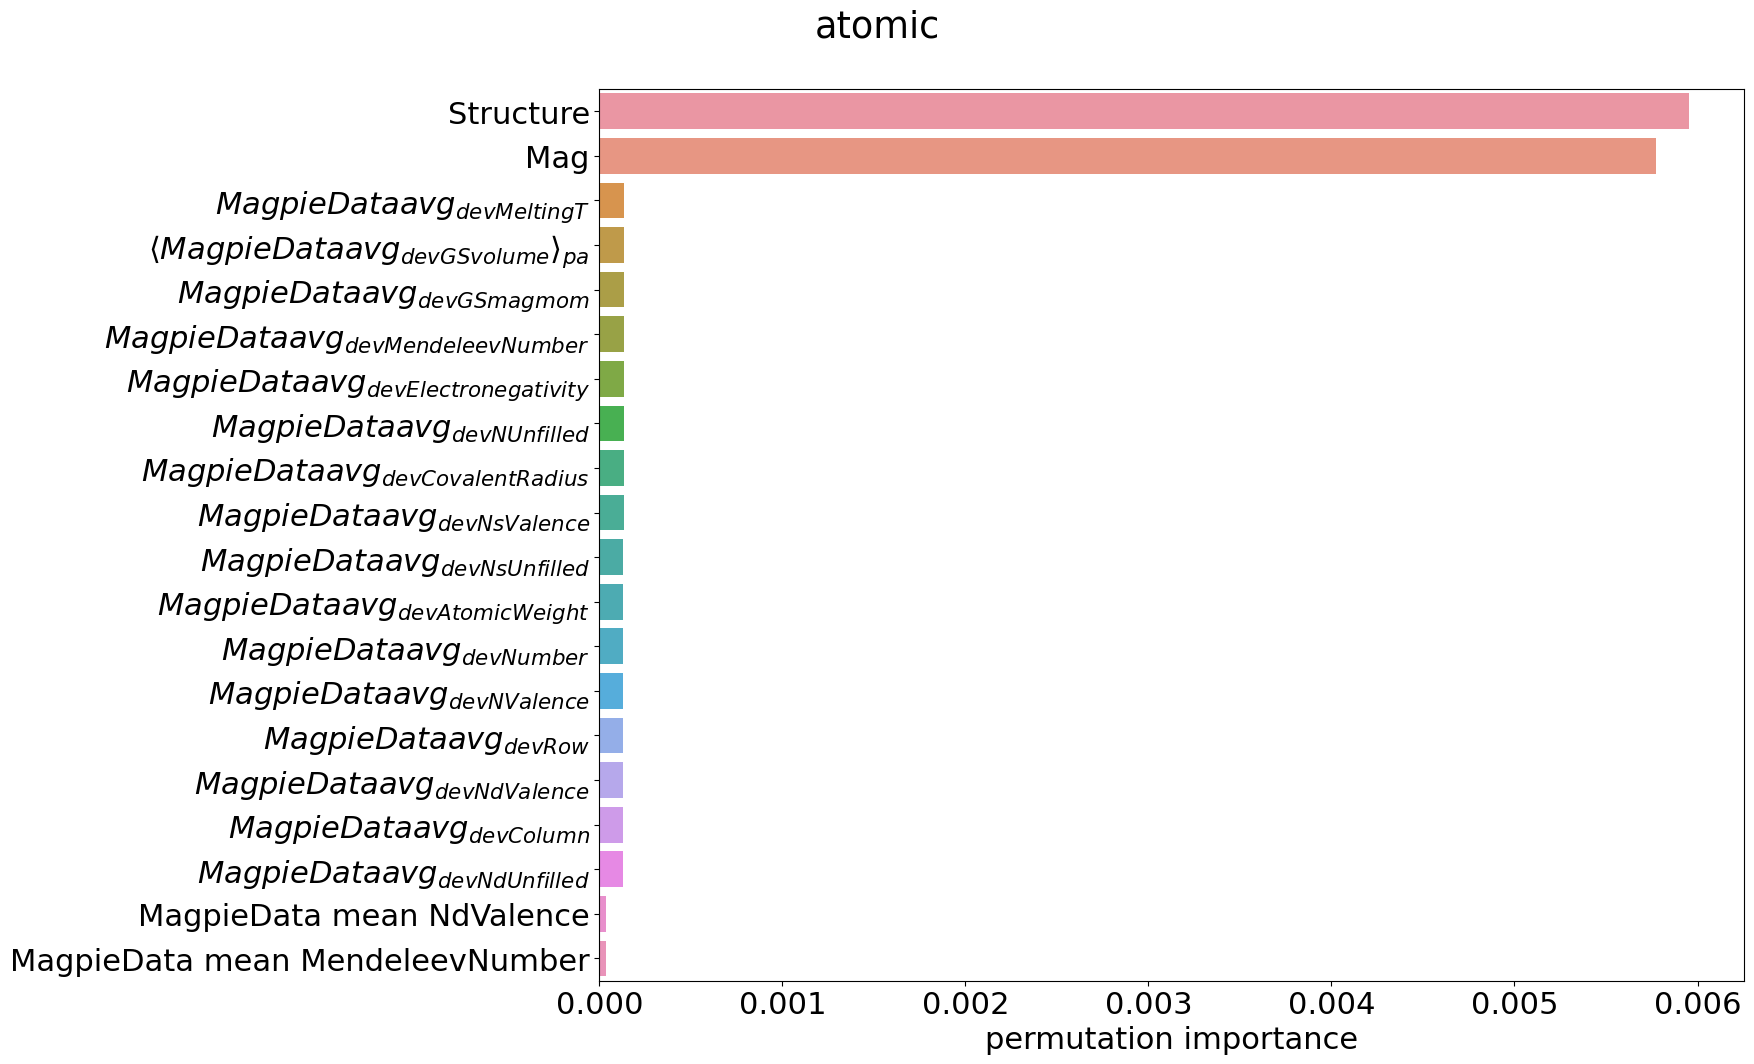

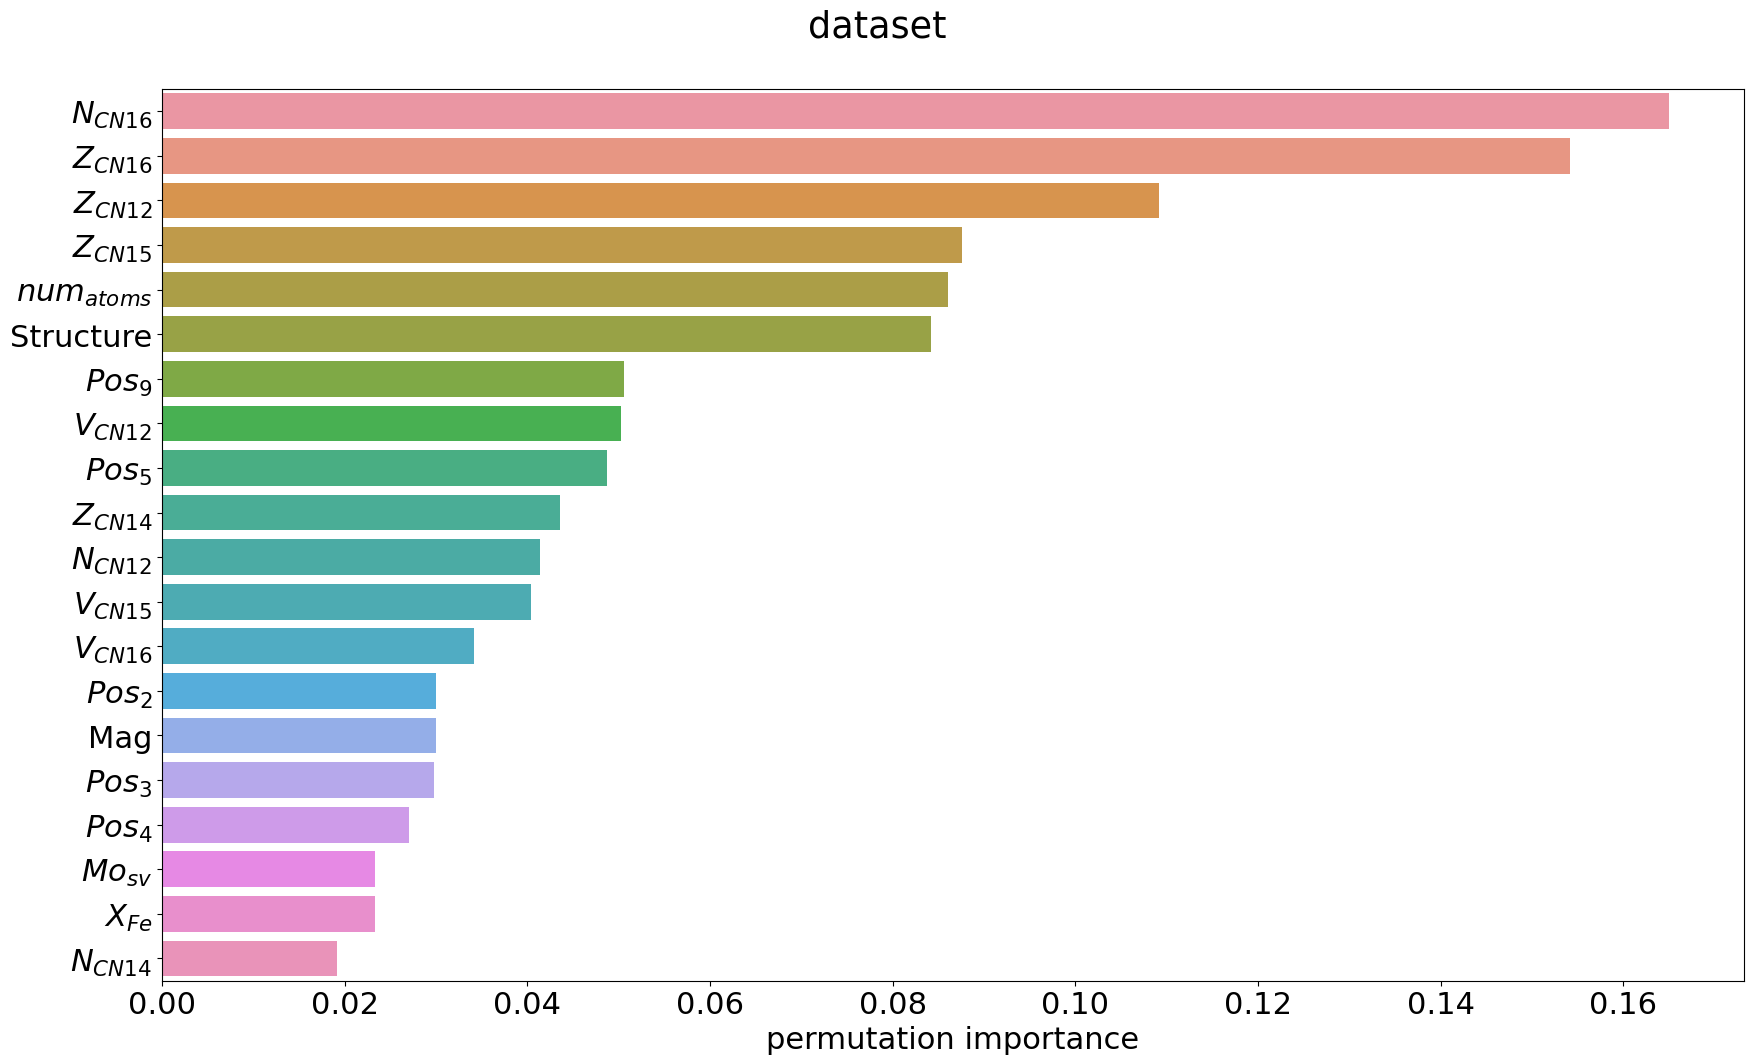

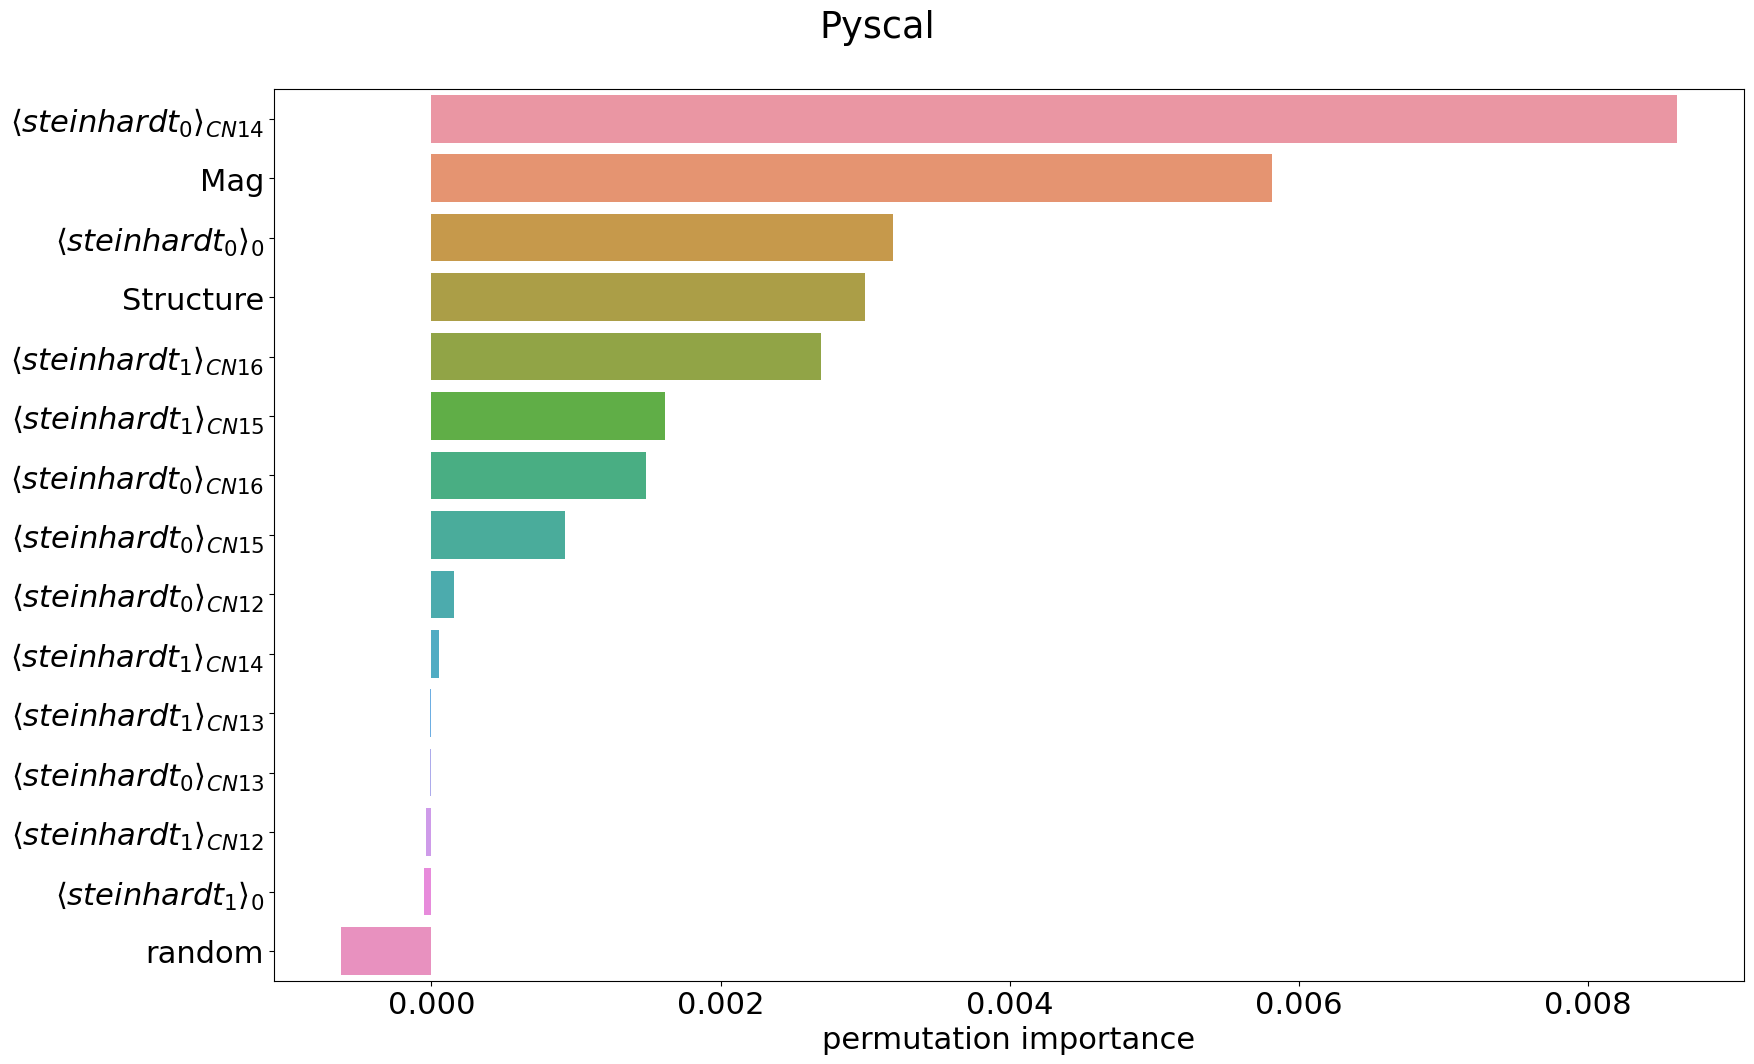

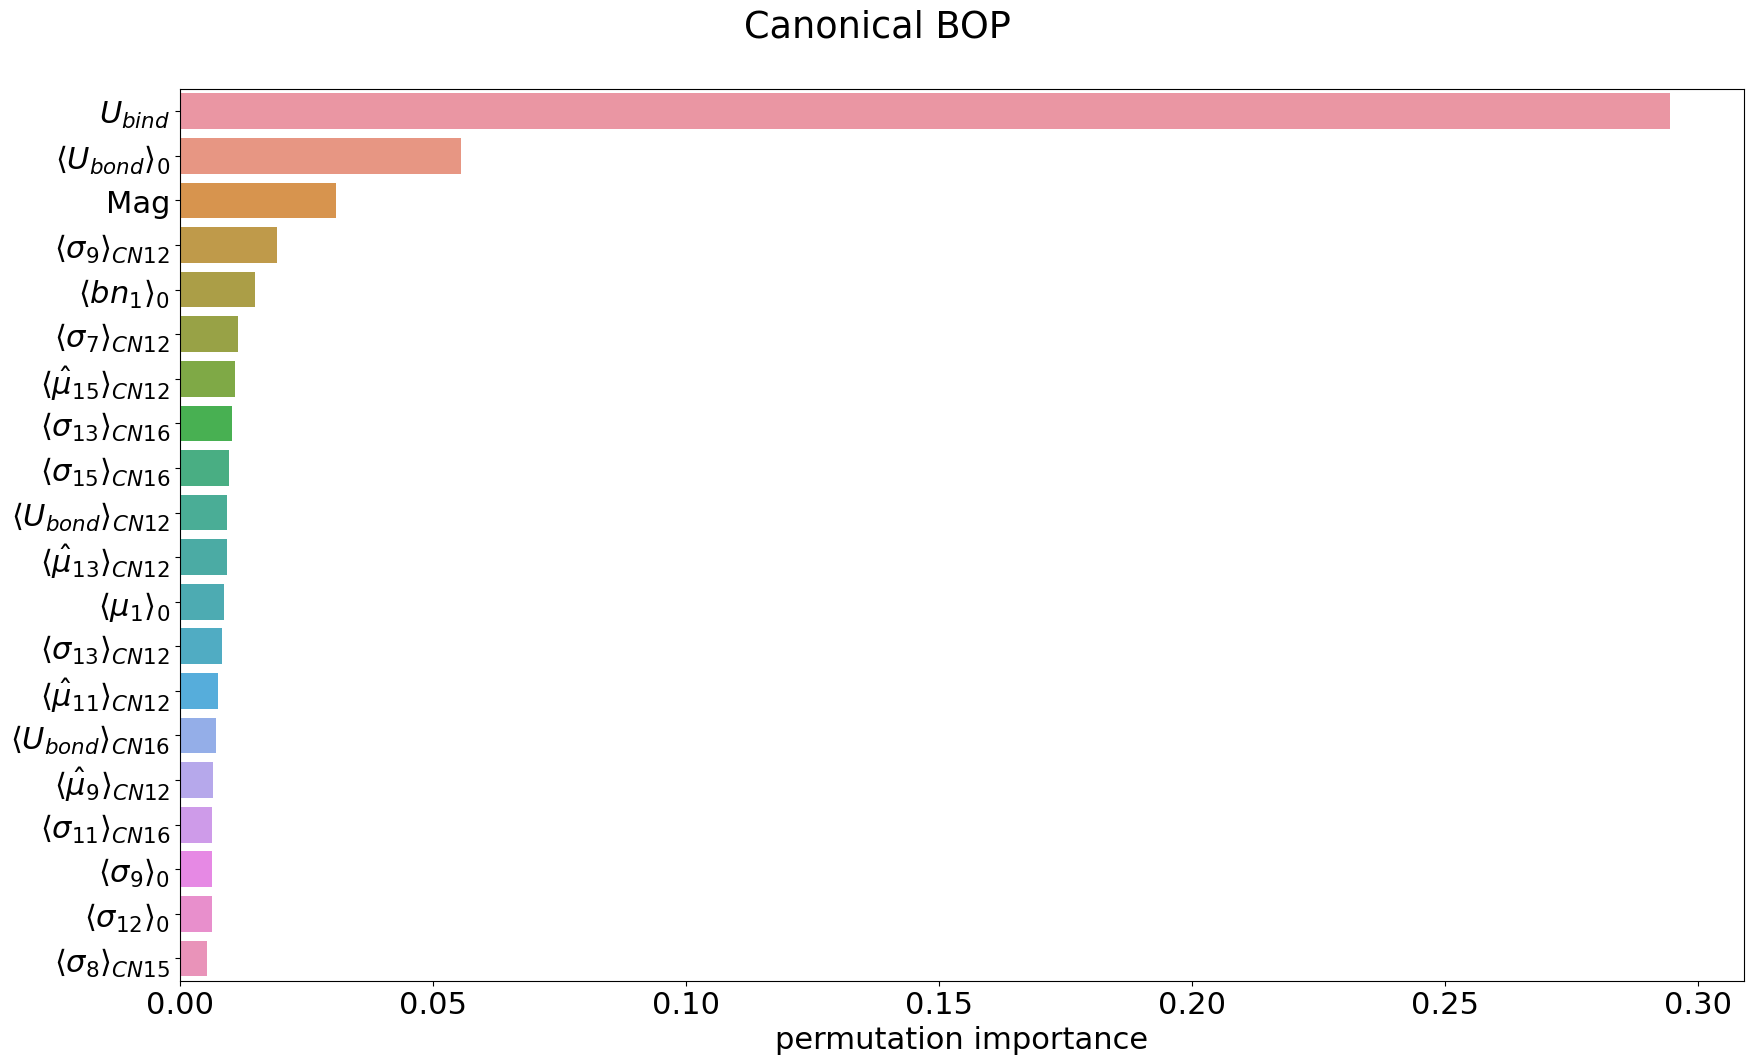

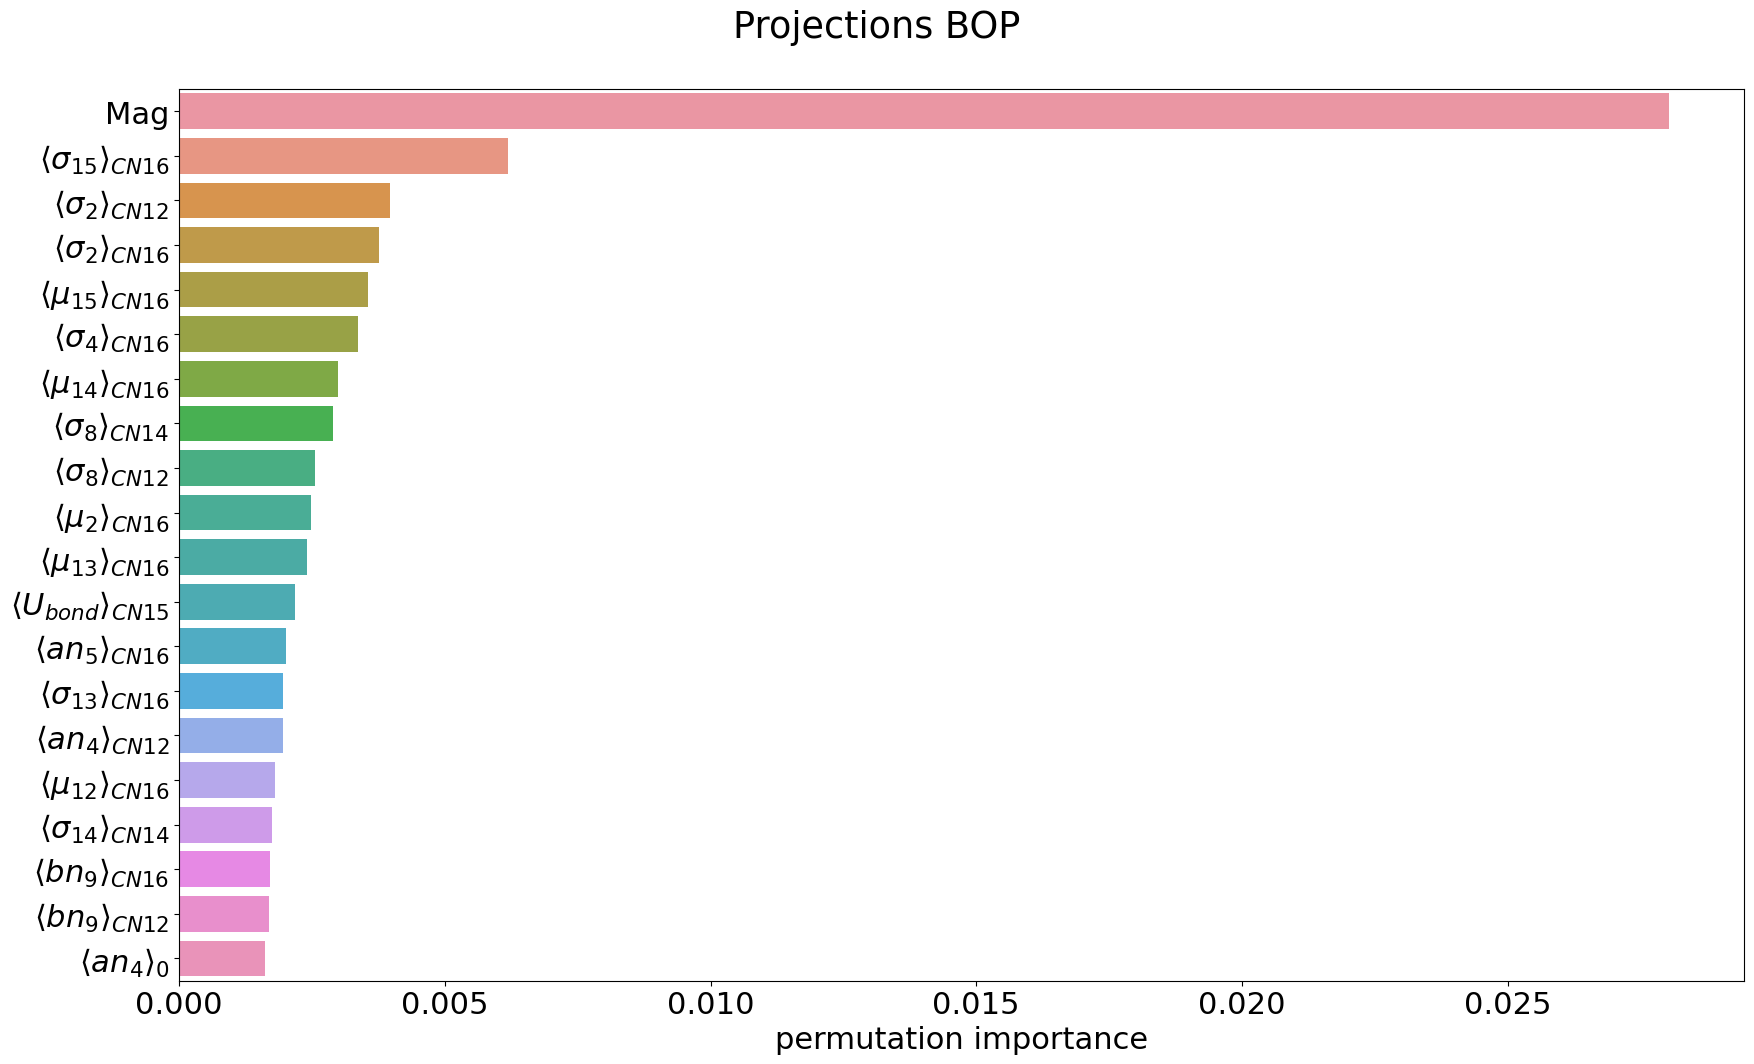

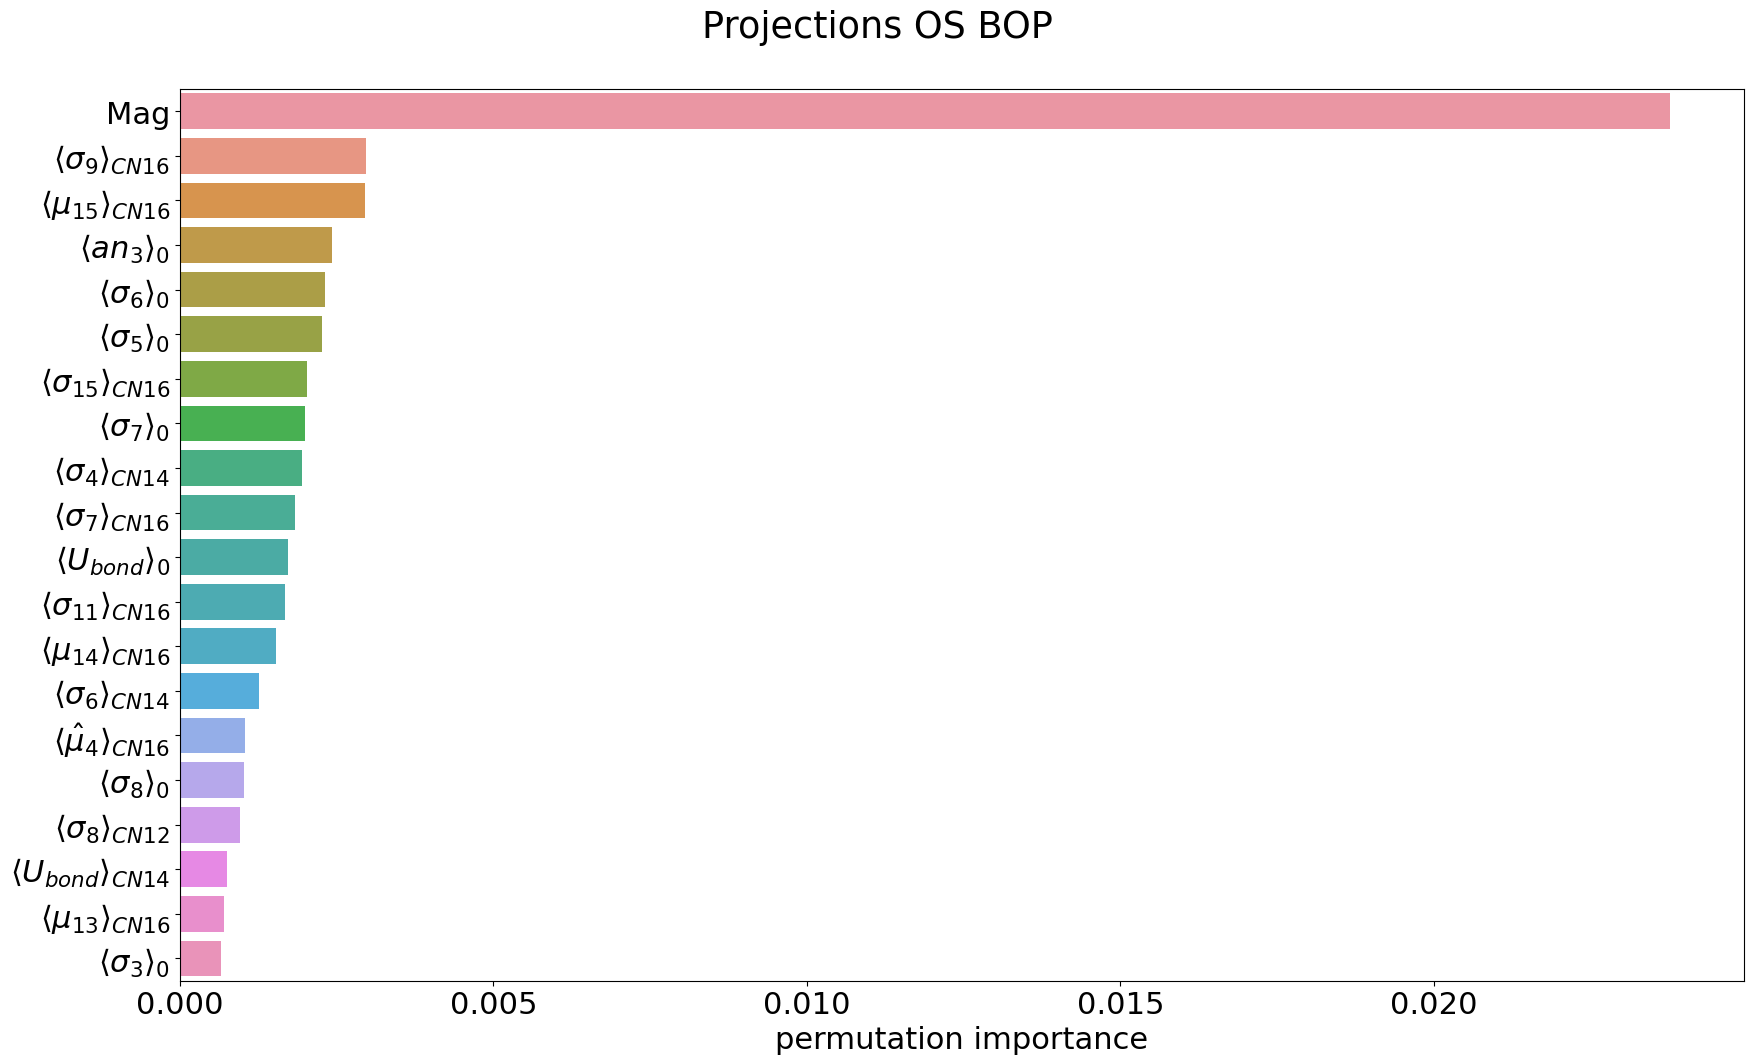

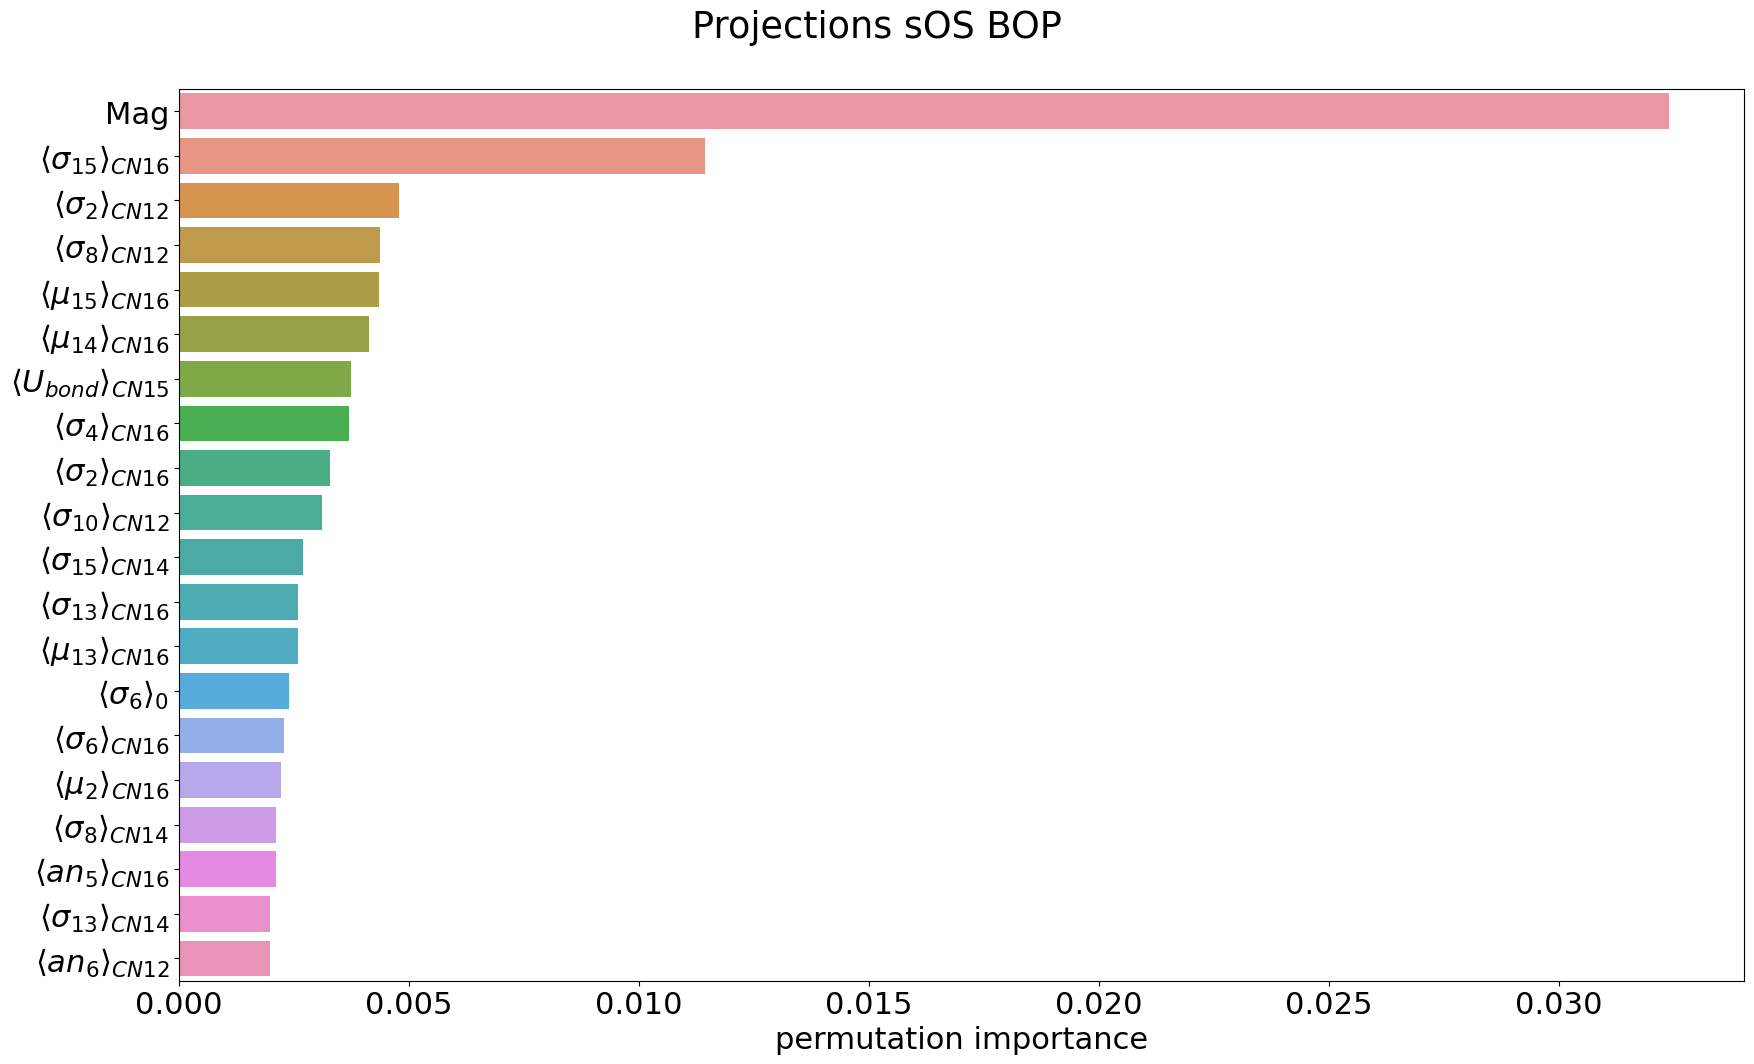

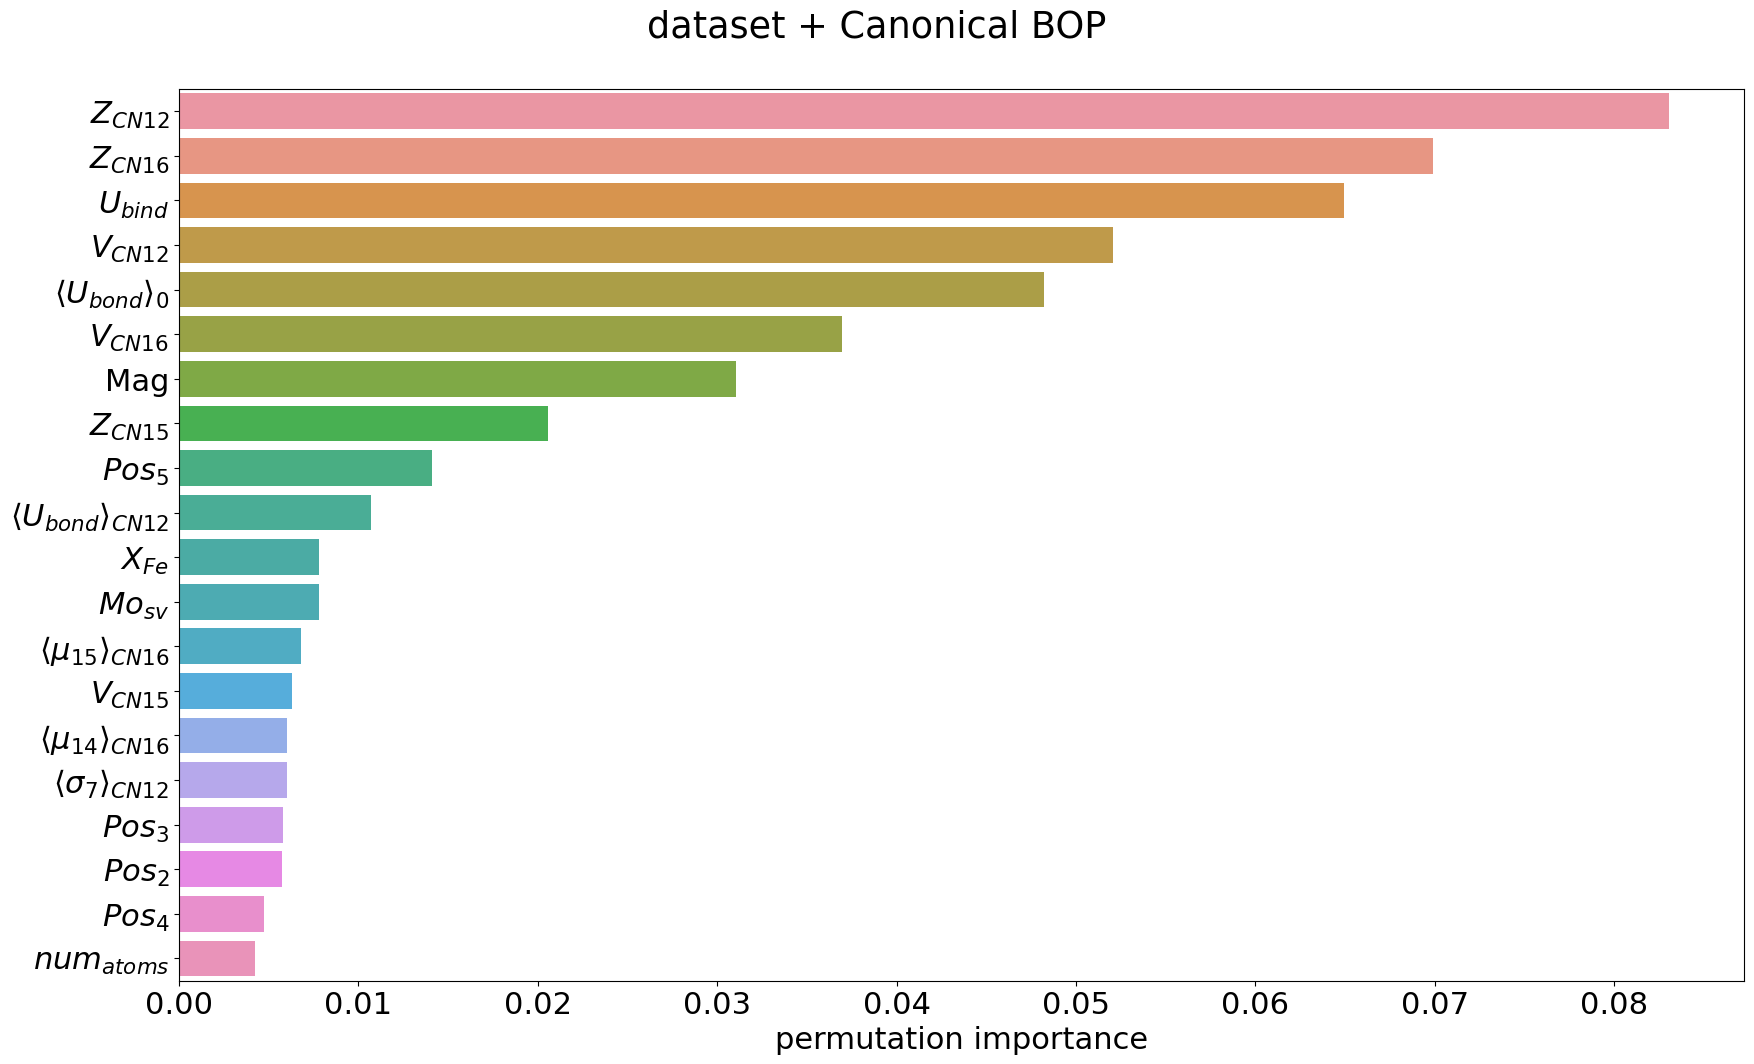

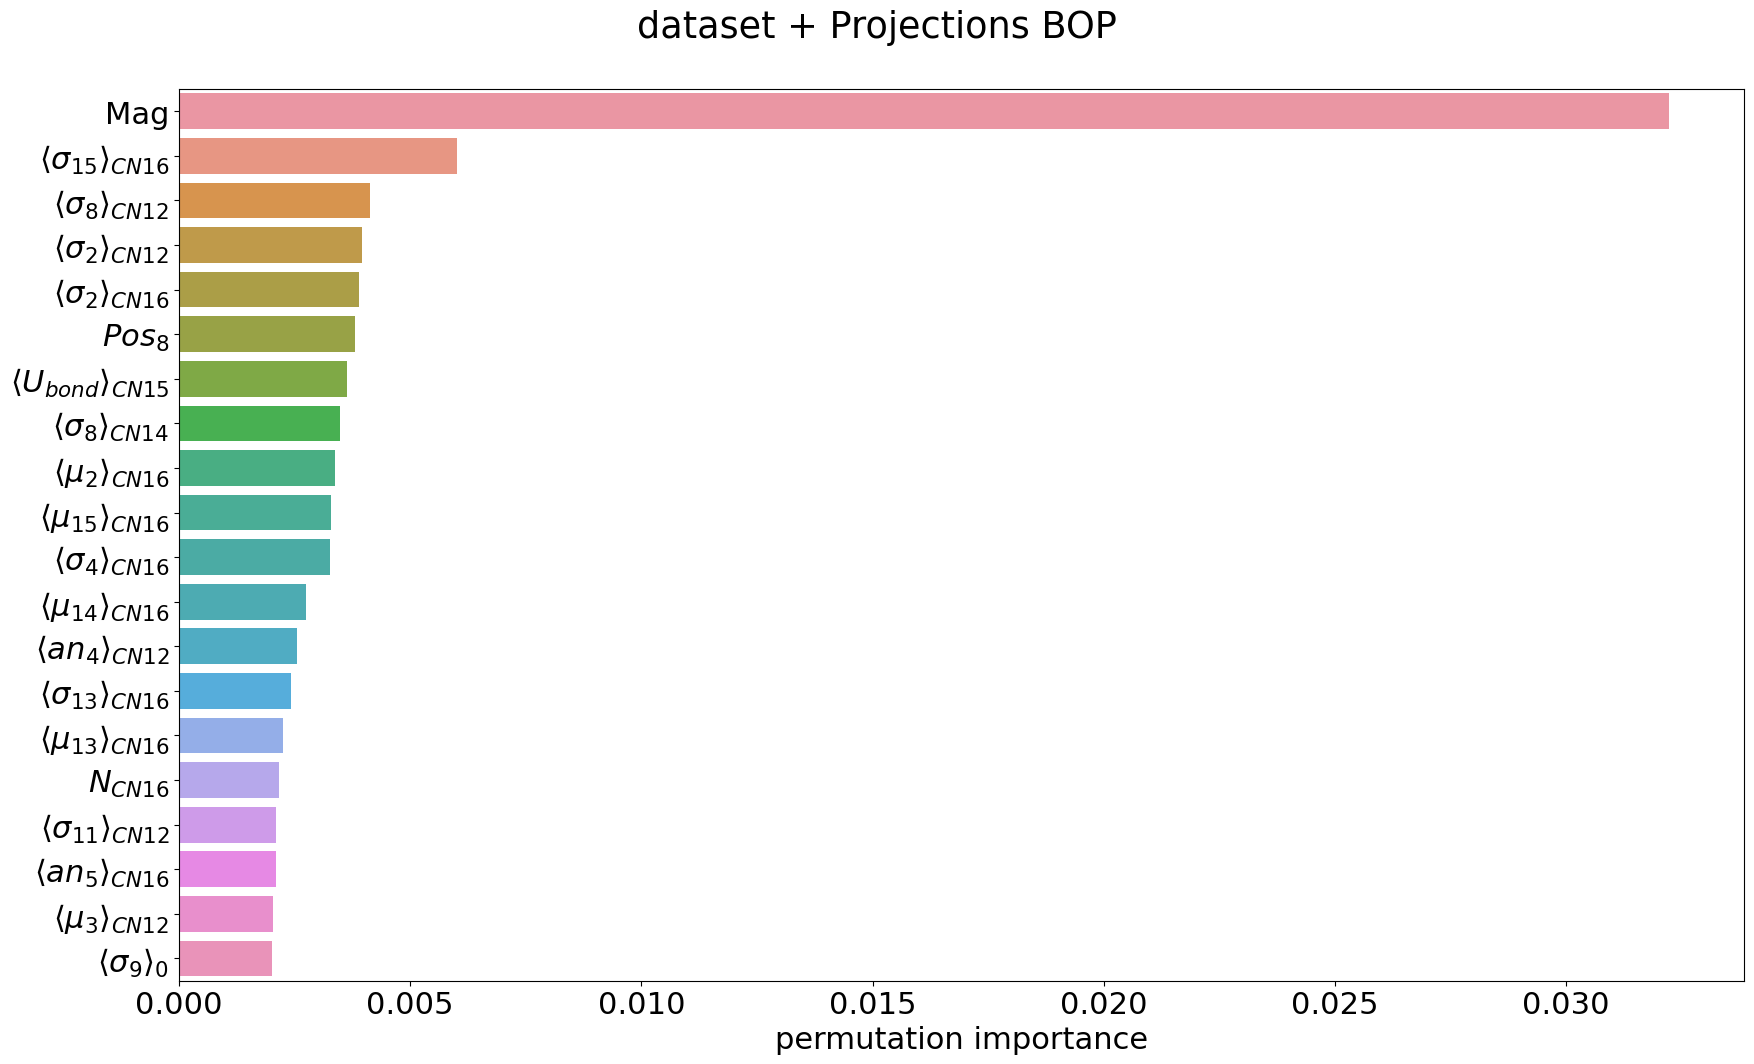

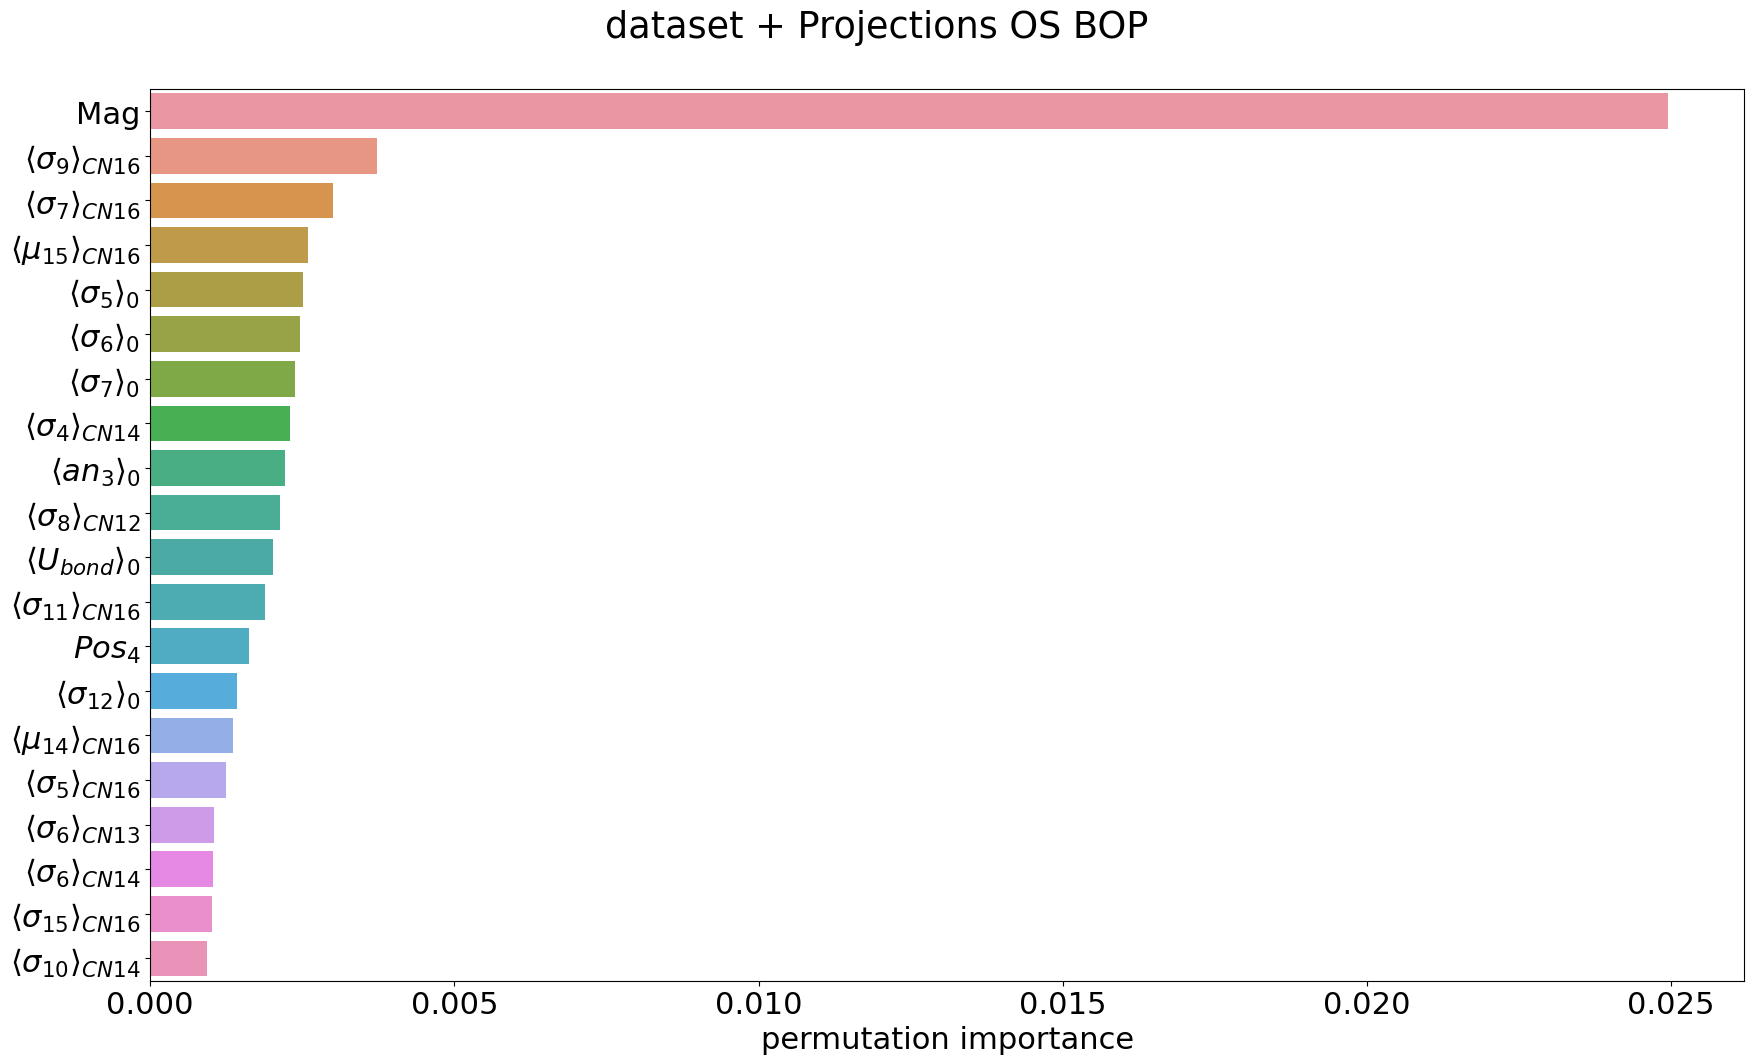

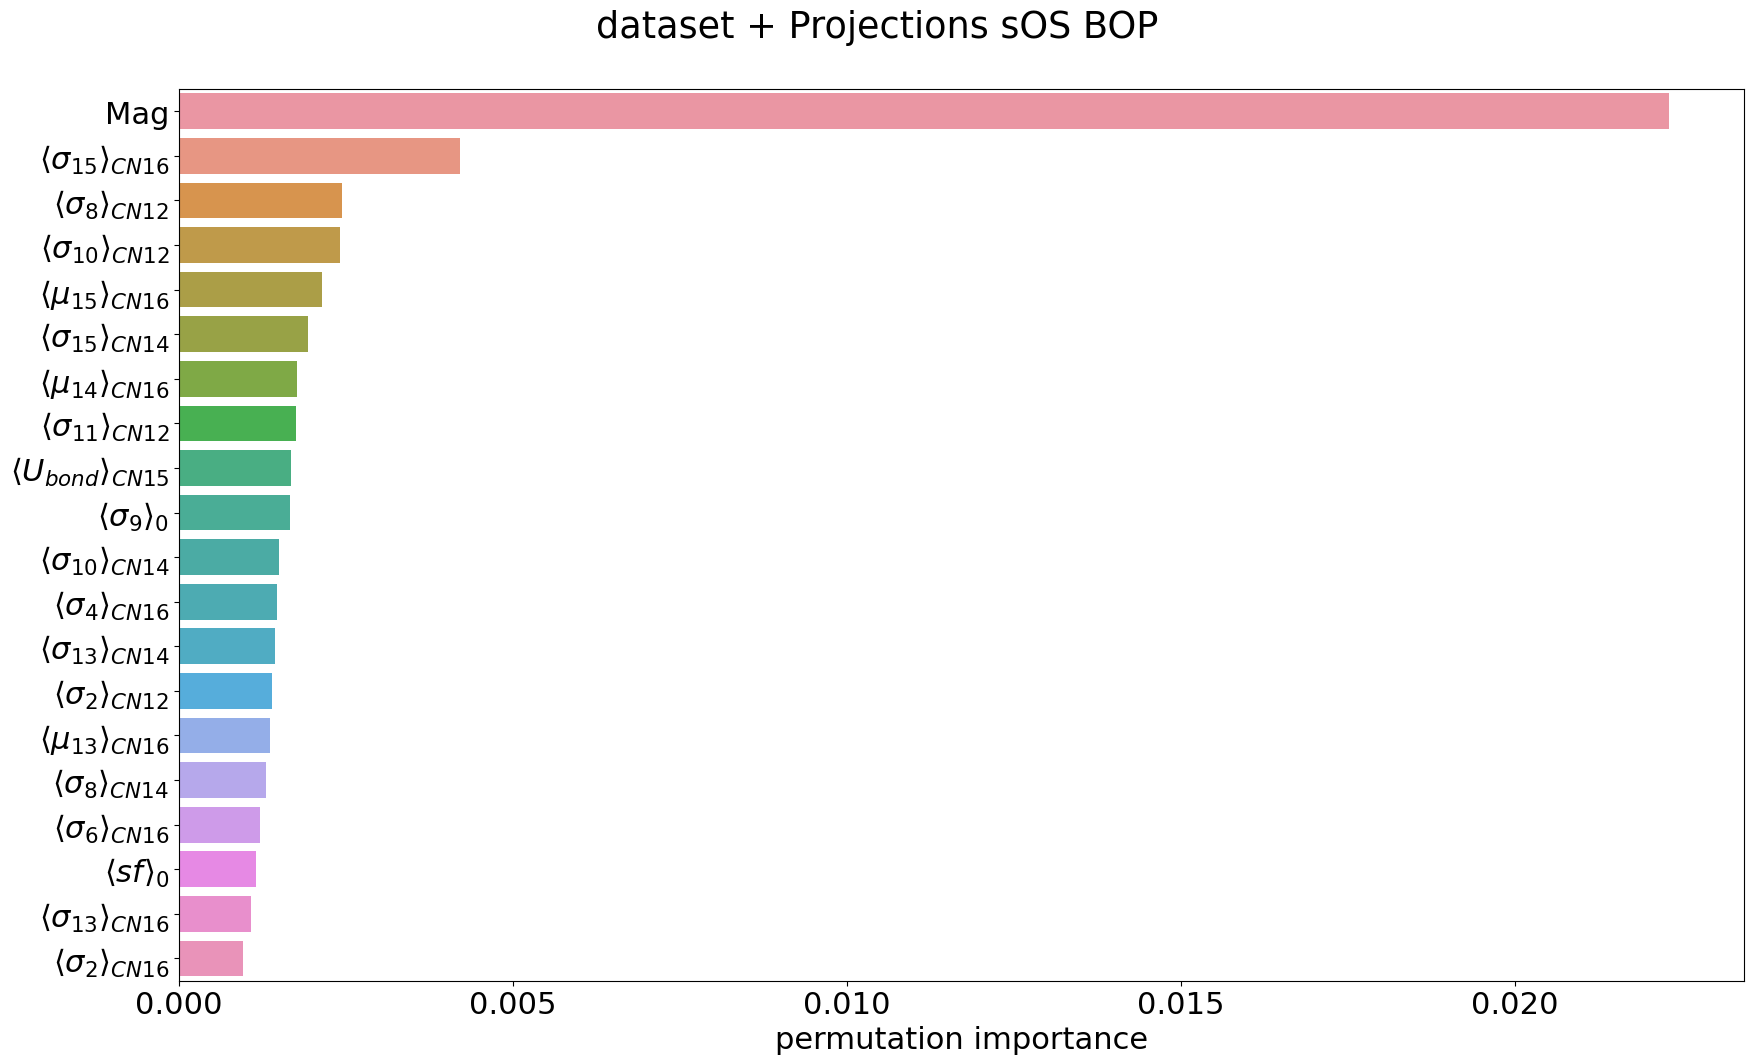

In [152]:
for (model, name), timp in importances.items():
    fig, ax = plt.subplots(figsize=(18, 11))
    x = timp['importances_mean'][:20]
    sns.barplot(y=timp.index[:20], x=x , ax=ax)
    ylabels = [get_str_formatted(fname) for fname in x.index]
    ax.set_xlabel('permutation importance')
    ax.set_yticklabels(ylabels)
    fig.suptitle(name)
    fig.tight_layout()
    nameforfile  = name.replace(' ','')
    fig.savefig(f'{DS.dataset}/graphs/{DS.dataset}_permutation_importance_{nameforfile}.eps')